# Assignment 24 — Descriptive Statistics on Food Delivery + Iris Datasets

## Topic Explanation

### What is Descriptive Statistics?
**Descriptive Statistics** is the branch of statistics that summarizes and describes the main features of a dataset using **numbers** rather than predictions. It answers questions like:
- What's the typical value? (central tendency)
- How spread out are the values? (variability)
- What's the shape of the distribution?

It's the **first thing** you do when exploring any new dataset — before any modeling.

### Compare with Inferential Statistics
- **Descriptive** — summarizes the data you have
- **Inferential** — makes predictions/generalizations from a sample to a larger population (hypothesis tests, confidence intervals, regression)

### Two Categories of Descriptive Statistics

#### 1. Measures of Central Tendency
"Where is the center of the data?"

| Measure | Formula | When to Use |
|---------|---------|-------------|
| **Mean** | Σx / n | Symmetric data without outliers |
| **Median** | Middle value when sorted | Skewed data or outliers present |
| **Mode** | Most frequent value | Categorical data |

- **Mean** is sensitive to outliers — one extreme value drags it
- **Median** is robust — only the position matters
- **Mode** can be used for any data type

#### 2. Measures of Variability (Dispersion)
"How spread out is the data?"

| Measure | Formula | Meaning |
|---------|---------|---------|
| **Range** | max − min | Total spread |
| **Variance** | Σ(x − mean)² / (n−1) | Average squared deviation |
| **Standard Deviation** | √variance | Spread in original units |
| **IQR** | Q3 − Q1 | Spread of middle 50% |

- **Range** is simple but only uses two values
- **Standard deviation** uses all values; same units as the data
- **IQR** is robust to outliers

### Percentiles and Quartiles

A **percentile** is the value below which a given % of data falls:
- **25th percentile (Q1)** — first quartile, 25% of data is below this
- **50th percentile (Q2 / Median)** — second quartile, half the data is below
- **75th percentile (Q3)** — third quartile, 75% of data is below

### Group-Wise Statistics
Often the most useful insight comes from **summarizing within groups** rather than across the whole dataset. For example:
- Average delivery time across all orders may be misleading
- Average delivery time **grouped by traffic level** reveals real patterns

In pandas this is done with **`.groupby('column').agg([statistics])`**.

### About the Datasets

#### Food Delivery Times Dataset
A real-world delivery dataset with:
- **Numeric variables**: `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, `Delivery_Time_min`
- **Categorical variables**: `Weather`, `Traffic_Level`, `Time_of_Day`, `Vehicle_Type`

We'll group numeric variables by `Traffic_Level` (Low / Medium / High) — a natural grouping that should clearly affect delivery time.

#### Iris Dataset
The most famous dataset in ML. 150 iris flowers across 3 species (setosa, versicolor, virginica), each described by 4 measurements (sepal length, sepal width, petal length, petal width).

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations, groupby, describe
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Part 1: Food Delivery Dataset — Group-wise Summary Statistics

### Step 2: Load the Food Delivery Dataset

In [2]:
# Load the food delivery dataset
df = pd.read_csv('food_delivery_times.csv')
print("Shape:", df.shape)
df.head()

Shape: (300, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,1,11.89,Snowy,High,Morning,Bike,8,6.0,69
1,2,4.59,Clear,High,Night,Car,12,1.8,47
2,3,1.95,Snowy,High,Morning,Car,17,6.0,46
3,4,9.56,Clear,Medium,Night,Bike,14,2.3,53
4,5,12.50,Windy,Low,Afternoon,Scooter,22,0.2,70


In [3]:
# Inspect column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                300 non-null    int64  
 1   Distance_km             300 non-null    float64
 2   Weather                 300 non-null    str    
 3   Traffic_Level           300 non-null    str    
 4   Time_of_Day             300 non-null    str    
 5   Vehicle_Type            300 non-null    str    
 6   Preparation_Time_min    300 non-null    int64  
 7   Courier_Experience_yrs  300 non-null    float64
 8   Delivery_Time_min       300 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.2 KB


In [4]:
# Check what categorical groupings are available
print("Traffic_Level distribution:")
print(df['Traffic_Level'].value_counts())
print("\nWeather distribution:")
print(df['Weather'].value_counts())
print("\nTime_of_Day distribution:")
print(df['Time_of_Day'].value_counts())

Traffic_Level distribution:
Traffic_Level
High      109
Low       102
Medium     89
Name: count, dtype: int64

Weather distribution:
Weather
Rainy    67
Clear    65
Snowy    63
Windy    58
Foggy    47
Name: count, dtype: int64

Time_of_Day distribution:
Time_of_Day
Afternoon    89
Night        78
Morning      71
Evening      62
Name: count, dtype: int64


### Step 3: Summary Statistics — Whole Dataset

`describe()` returns count, mean, std, min, 25%, 50% (median), 75%, max for every numeric column.

In [5]:
# Whole-dataset summary
df.describe().round(3)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,300.000,300.000,300.000,300.000,300.000
mean,150.500,9.913,17.410,4.449,63.863
std,86.747,5.628,6.959,2.609,19.574
min,1.000,0.520,5.000,0.000,12.000
25%,75.750,5.192,12.000,2.200,50.000
50%,150.500,9.650,18.000,4.450,63.000
75%,225.250,14.590,23.000,6.700,77.000
max,300.000,19.890,29.000,9.000,119.000


### Step 4: Summary Statistics Grouped by `Traffic_Level`

This is the core of the assignment — group numeric variables by the categorical `Traffic_Level` variable.

In [6]:
# Group by Traffic_Level and compute multiple statistics for each numeric column
numeric_cols = ['Distance_km', 'Preparation_Time_min',
                'Courier_Experience_yrs', 'Delivery_Time_min']

grouped = df.groupby('Traffic_Level')[numeric_cols].agg(
    ['mean', 'median', 'min', 'max', 'std']
).round(3)

print("Group-wise summary statistics by Traffic_Level:")
grouped

Group-wise summary statistics by Traffic_Level:


Distance_km                            Preparation_Time_min  \
                     mean median   min    max    std                 mean   
Traffic_Level                                                               
High                9.845   8.92  0.78  19.89  5.876               16.376   
Low                10.248  10.49  0.52  19.71  5.534               18.078   
Medium              9.613   9.68  0.54  19.75  5.466               17.910   

                                    Courier_Experience_yrs                   \
              median min max    std                   mean median  min  max   
Traffic_Level                                                                 
High            16.0   5  29  6.927                  4.144   4.00  0.1  9.0   
Low             19.0   5  29  7.034                  4.656   4.65  0.0  8.9   
Medium          18.0   5  29  6.838                  4.587   4.60  0.3  8.8   

                     Delivery_Time_min                          
                 std              mean median min  max     std  
Traffic_Level                                                   
High           2.636            70.835   71.0  30  119  19.851  
Low            2.800            57.941   58.5  12   98  18.806  
Medium         2.328            62.112   63.0  24  101  17.558

### Step 5: Focus on Delivery Time

Delivery time is the most important variable. Let's see how it varies by traffic level alone.

In [7]:
# Detailed delivery time stats per traffic level
print("Delivery_Time_min — detailed statistics per Traffic_Level:")
df.groupby('Traffic_Level')['Delivery_Time_min'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max',
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.75)]
).rename(columns={
    '<lambda_0>': 'Q1 (25%)',
    '<lambda_1>': 'Q3 (75%)'
}).round(2)

Delivery_Time_min — detailed statistics per Traffic_Level:


,count,mean,median,std,min,max,Q1 (25%),Q3 (75%)
Traffic_Level,,,,,,,,
High,109,70.83,71.0,19.85,30,119,56.00,90.0
Low,102,57.94,58.5,18.81,12,98,43.75,70.0
Medium,89,62.11,63.0,17.56,24,101,48.00,74.0


### Step 6: Create a List Containing a Numeric Value Per Category

The assignment asks for "a list that contains a numeric value for each response to the categorical variable." This means: for each traffic level, compute one number (e.g., mean delivery time).

In [8]:
# Mean delivery time per Traffic_Level — produces 3 numbers
mean_delivery_per_traffic = df.groupby('Traffic_Level')['Delivery_Time_min'].mean().tolist()

print("Categories:", df['Traffic_Level'].unique().tolist())
print("Mean delivery times per category:", [round(x, 2) for x in mean_delivery_per_traffic])

Categories: ['High', 'Medium', 'Low']
Mean delivery times per category: [70.83, 57.94, 62.11]


In [9]:
# Same approach for several variables
for var in numeric_cols:
    means = df.groupby('Traffic_Level')[var].mean().tolist()
    print(f"Mean {var:<25} per traffic level: {[round(x, 2) for x in means]}")

Mean Distance_km               per traffic level: [9.84, 10.25, 9.61]
Mean Preparation_Time_min      per traffic level: [16.38, 18.08, 17.91]
Mean Courier_Experience_yrs    per traffic level: [4.14, 4.66, 4.59]
Mean Delivery_Time_min         per traffic level: [70.83, 57.94, 62.11]


### Step 7: Group by Other Categorical Variables Too

Same approach applied to Weather and Time_of_Day, just to demonstrate.

In [10]:
print("Mean Delivery_Time_min by Weather:")
print(df.groupby('Weather')['Delivery_Time_min'].mean().round(2))

print("\nMean Delivery_Time_min by Time_of_Day:")
print(df.groupby('Time_of_Day')['Delivery_Time_min'].mean().round(2))

print("\nMean Delivery_Time_min by Vehicle_Type:")
print(df.groupby('Vehicle_Type')['Delivery_Time_min'].mean().round(2))

Mean Delivery_Time_min by Weather:
Weather
Clear    60.11
Foggy    65.38
Rainy    64.19
Snowy    68.38
Windy    61.55
Name: Delivery_Time_min, dtype: float64

Mean Delivery_Time_min by Time_of_Day:
Time_of_Day
Afternoon    66.24
Evening      60.90
Morning      62.85
Night        64.44
Name: Delivery_Time_min, dtype: float64

Mean Delivery_Time_min by Vehicle_Type:
Vehicle_Type
Bike       63.56
Car        62.80
Scooter    65.25
Name: Delivery_Time_min, dtype: float64


### Step 8: Visualize Group Differences

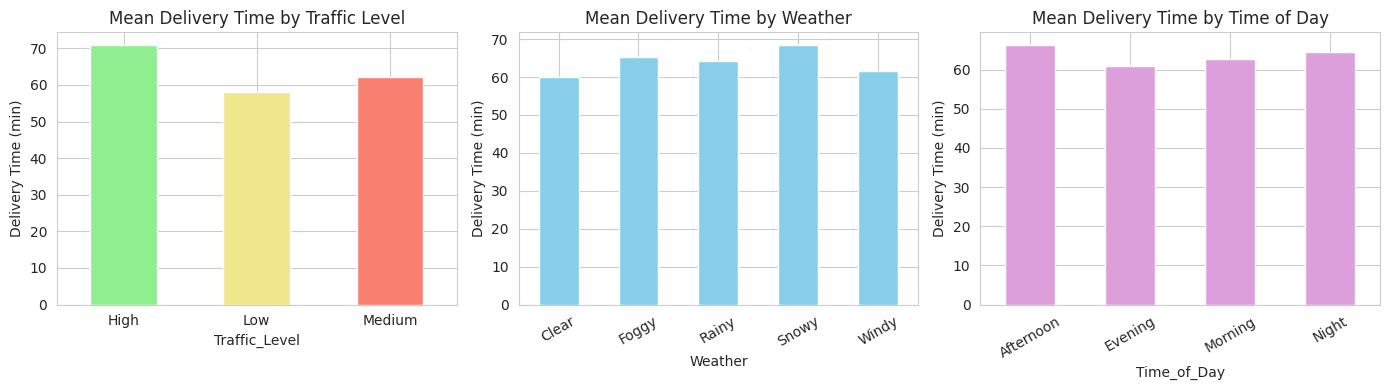

In [11]:
# Bar plot — mean delivery time per traffic level
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df.groupby('Traffic_Level')['Delivery_Time_min'].mean().plot(
    kind='bar', ax=axes[0], color=['lightgreen','khaki','salmon'])
axes[0].set_title('Mean Delivery Time by Traffic Level')
axes[0].set_ylabel('Delivery Time (min)')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Weather')['Delivery_Time_min'].mean().plot(
    kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Mean Delivery Time by Weather')
axes[1].set_ylabel('Delivery Time (min)')
axes[1].tick_params(axis='x', rotation=30)

df.groupby('Time_of_Day')['Delivery_Time_min'].mean().plot(
    kind='bar', ax=axes[2], color='plum')
axes[2].set_title('Mean Delivery Time by Time of Day')
axes[2].set_ylabel('Delivery Time (min)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

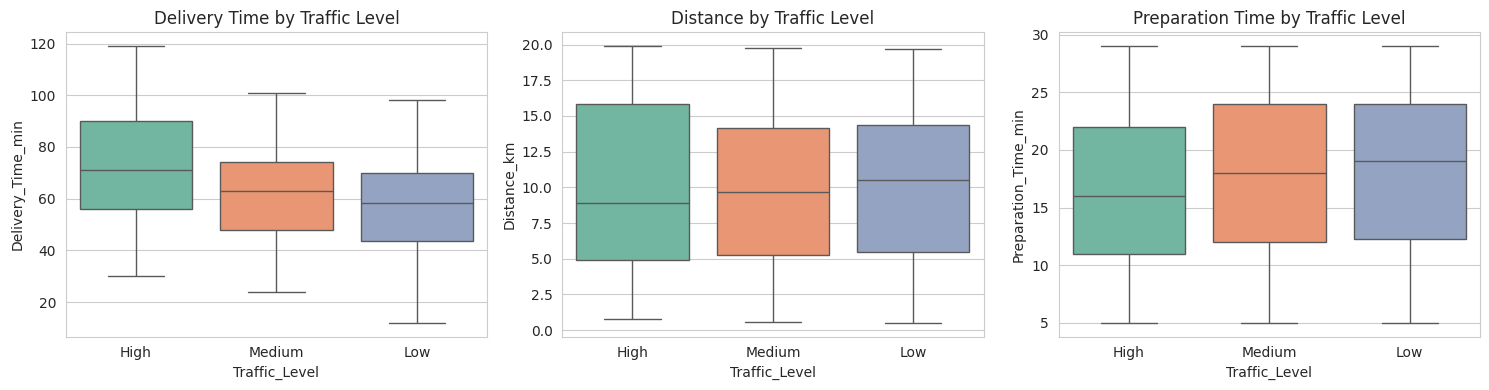

In [12]:
# Boxplots — show distribution per traffic level
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df, ax=axes[0],
            hue='Traffic_Level', palette='Set2', legend=False)
axes[0].set_title('Delivery Time by Traffic Level')

sns.boxplot(x='Traffic_Level', y='Distance_km', data=df, ax=axes[1],
            hue='Traffic_Level', palette='Set2', legend=False)
axes[1].set_title('Distance by Traffic Level')

sns.boxplot(x='Traffic_Level', y='Preparation_Time_min', data=df, ax=axes[2],
            hue='Traffic_Level', palette='Set2', legend=False)
axes[2].set_title('Preparation Time by Traffic Level')

plt.tight_layout()
plt.show()

## Part 2: Iris Dataset — Per-Species Statistics

### Step 9: Load the Iris Dataset

In [13]:
# Load the Iris dataset
iris = pd.read_csv('iris.csv')
print("Shape:", iris.shape)
iris.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
# Class distribution — 50 each is typical
print("Species distribution:")
print(iris['species'].value_counts())

Species distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### Step 10: Statistical Details of `Iris-setosa`

`describe()` automatically gives count, mean, std, min, 25/50/75 percentiles, max.

In [15]:
# Filter to setosa rows only, then describe
setosa_stats = iris[iris['species'] == 'Iris-setosa'].describe().round(3)
print("Iris-setosa — statistical summary:")
setosa_stats

Iris-setosa — statistical summary:


,sepal_length,sepal_width,petal_length,petal_width
count,50.000,50.000,50.000,50.000
mean,5.006,3.428,1.462,0.246
std,0.352,0.379,0.174,0.105
min,4.300,2.300,1.000,0.100
25%,4.800,3.200,1.400,0.200
50%,5.000,3.400,1.500,0.200
75%,5.200,3.675,1.575,0.300
max,5.800,4.400,1.900,0.600


### Step 11: Statistical Details of `Iris-versicolor`

In [16]:
versicolor_stats = iris[iris['species'] == 'Iris-versicolor'].describe().round(3)
print("Iris-versicolor — statistical summary:")
versicolor_stats

Iris-versicolor — statistical summary:


,sepal_length,sepal_width,petal_length,petal_width
count,50.000,50.000,50.00,50.000
mean,5.936,2.770,4.26,1.326
std,0.516,0.314,0.47,0.198
min,4.900,2.000,3.00,1.000
25%,5.600,2.525,4.00,1.200
50%,5.900,2.800,4.35,1.300
75%,6.300,3.000,4.60,1.500
max,7.000,3.400,5.10,1.800


### Step 12: Statistical Details of `Iris-virginica`

In [17]:
virginica_stats = iris[iris['species'] == 'Iris-virginica'].describe().round(3)
print("Iris-virginica — statistical summary:")
virginica_stats

Iris-virginica — statistical summary:


,sepal_length,sepal_width,petal_length,petal_width
count,50.000,50.000,50.000,50.000
mean,6.588,2.974,5.552,2.026
std,0.636,0.322,0.552,0.275
min,4.900,2.200,4.500,1.400
25%,6.225,2.800,5.100,1.800
50%,6.500,3.000,5.550,2.000
75%,6.900,3.175,5.875,2.300
max,7.900,3.800,6.900,2.500


### Step 13: Compare All Species Side-by-Side

In [18]:
# Use groupby to show all species in one combined table
iris.groupby('species').agg(['mean', 'median', 'std', 'min', 'max']).round(3)

sepal_length                         sepal_width         \
                        mean median    std  min  max        mean median   
species                                                                   
Iris-setosa            5.006    5.0  0.352  4.3  5.8       3.428    3.4   
Iris-versicolor        5.936    5.9  0.516  4.9  7.0       2.770    2.8   
Iris-virginica         6.588    6.5  0.636  4.9  7.9       2.974    3.0   

                                 petal_length                          \
                   std  min  max         mean median    std  min  max   
species                                                                 
Iris-setosa      0.379  2.3  4.4        1.462   1.50  0.174  1.0  1.9   
Iris-versicolor  0.314  2.0  3.4        4.260   4.35  0.470  3.0  5.1   
Iris-virginica   0.322  2.2  3.8        5.552   5.55  0.552  4.5  6.9   

                petal_width                          
                       mean median    std  min  max  
species                                              
Iris-setosa           0.246    0.2  0.105  0.1  0.6  
Iris-versicolor       1.326    1.3  0.198  1.0  1.8  
Iris-virginica        2.026    2.0  0.275  1.4  2.5

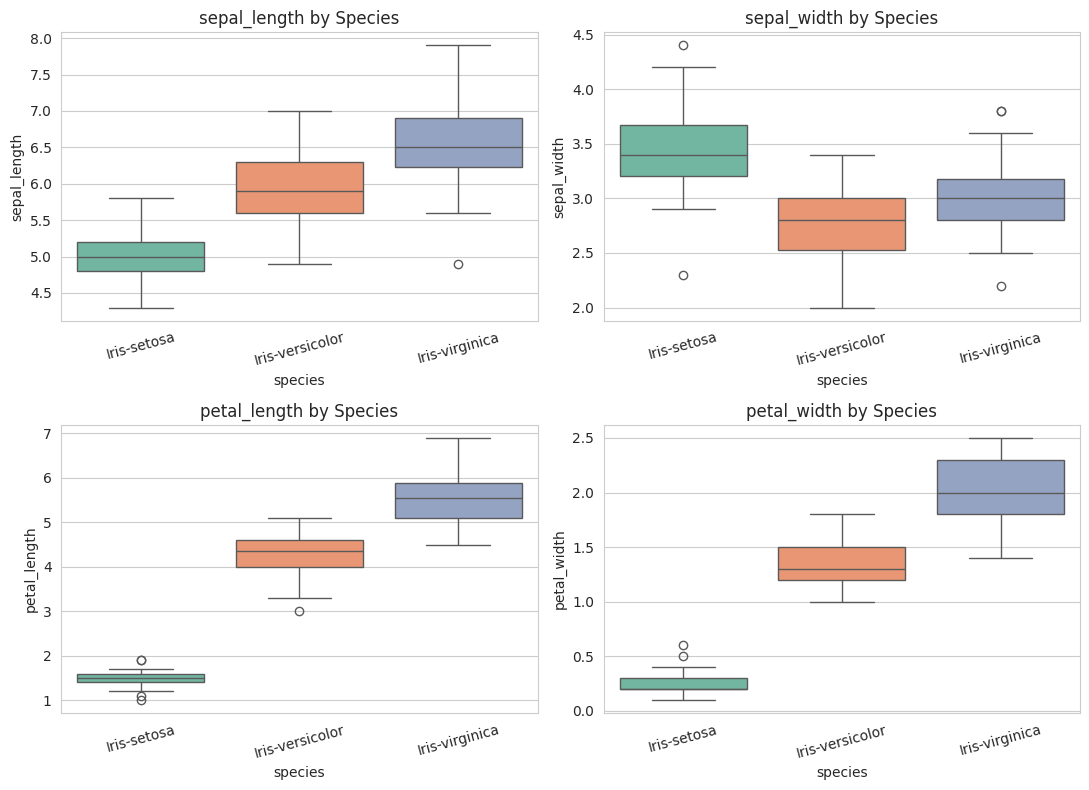

In [19]:
# Visualize — boxplots of all 4 measurements by species
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x='species', y=feat, data=iris, ax=ax,
                hue='species', palette='Set2', legend=False)
    ax.set_title(f'{feat} by Species')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Conclusion

We performed descriptive statistics on two datasets:

**Food Delivery dataset (Part 1):**
- Computed group-wise statistics (mean, median, min, max, std) for all numeric variables grouped by `Traffic_Level`.
- Created lists of single-number summaries (mean per category) for key variables.
- Demonstrated grouping by other categorical variables too (Weather, Time_of_Day, Vehicle_Type).
- Visualized the differences using bar charts and boxplots.

**Iris dataset (Part 2):**
- Used `iris[iris.species == X].describe()` to get full statistical details (count, mean, std, min, 25/50/75 percentiles, max) for each species separately.
- Confirmed that **petal measurements separate species better than sepal measurements** — Iris-setosa is clearly distinguishable from the others.
- Combined all three species into a single comparison table using `groupby`.

**Key insights:**
- **Food Delivery**: High traffic levels lead to noticeably longer delivery times. Weather and time-of-day also matter but to a lesser extent.
- **Iris**: Each species has clearly different petal measurements; sepal measurements overlap more between species.

Descriptive statistics by themselves don't predict anything — but they're essential for understanding your data, spotting outliers, and informing model choices.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, groupby, describe, agg |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner statistical visualization (boxplots) |

### Functions and Methods Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV
- `df.shape`, `df.head()`, `df.info()`, `df.describe()`
- `df['col'].value_counts()` — count occurrences of each category
- `df['col'].unique()` — get distinct values

#### Statistical Summary Methods (per Series)
- `.mean()` — average
- `.median()` — middle value
- `.std()` — standard deviation
- `.var()` — variance
- `.min()`, `.max()` — extremes
- `.quantile(q)` — percentile (e.g., 0.25, 0.5, 0.75)
- `.describe()` — count, mean, std, min, 25%, 50%, 75%, max all at once

#### Group Operations
- `df.groupby('col')` — split DataFrame into groups by a categorical column
- `.agg(['mean', 'median', 'std'])` — apply multiple statistics at once
- `.tolist()` — convert pandas Series to Python list
- Lambda inside agg: `lambda x: x.quantile(0.25)` for custom percentiles

#### Filtering
- `df[df['species'] == 'value']` — boolean indexing to filter rows

#### Visualization
- `sns.boxplot(x=cat, y=num, data=df)` — boxplot per category
- `series.plot(kind='bar')` — bar chart of a Series
- `plt.subplots(rows, cols, figsize)` — grid of plots
- `plt.tight_layout()` — auto-adjust spacing

### Key Concepts

#### Mean, Median, Mode
- **Mean** = sum / count; sensitive to outliers
- **Median** = middle value when sorted; robust
- **Mode** = most frequent value; works for any data type

#### Standard Deviation vs Variance
- **Variance** = average squared deviation from mean
- **Standard deviation** = √variance — same units as data, easier to interpret

#### Percentiles
A **percentile** is the value below which a given percentage of data falls.
- **25th percentile (Q1)** — 25% of data is below this
- **50th percentile (median)** — 50% below
- **75th percentile (Q3)** — 75% below

#### IQR (Interquartile Range)
**IQR = Q3 − Q1**, the spread of the middle 50% of data. Robust to outliers — used for outlier detection (Tukey's rule).

#### Group-wise Statistics
Computing statistics within categories rather than across the whole dataset. Often more meaningful — e.g., "average delivery time" is less useful than "average delivery time by traffic level."

The pandas pattern: **`.groupby(category).agg([statistic])`**

#### What `describe()` Returns

| Stat | Meaning |
|------|---------|
| count | number of non-NaN values |
| mean | arithmetic average |
| std | standard deviation |
| min | smallest value |
| 25% | first quartile (Q1) |
| 50% | median (Q2) |
| 75% | third quartile (Q3) |
| max | largest value |

## Viva Questions (with Answers)

### Conceptual

**Q1. What is descriptive statistics?**
Branch of statistics that summarizes and describes the main features of a dataset using numbers (mean, median, std, etc.).

**Q2. Difference between descriptive and inferential statistics?**
- **Descriptive** — summarizes the data you have
- **Inferential** — generalizes from a sample to a population (hypothesis tests, confidence intervals)

**Q3. What are the two main categories of descriptive statistics?**
- **Central tendency** — where is the center (mean, median, mode)
- **Variability** — how spread out (range, variance, std, IQR)

### Central Tendency

**Q4. Difference between mean and median?**
- **Mean** = arithmetic average; sensitive to outliers
- **Median** = middle value when sorted; robust to outliers

**Q5. When is median preferred over mean?**
When data has outliers or is skewed (e.g., income, house prices, delivery times with one extreme delay).

**Q6. What is the mode?**
Most frequently occurring value. Useful for categorical or discrete data.

### Variability

**Q7. What does standard deviation measure?**
The average distance of values from the mean — the spread of the data.

**Q8. Difference between variance and standard deviation?**
- **Variance** is the average squared deviation
- **Std** is the square root of variance — has the same units as the original data, so it's more interpretable

**Q9. What is the range?**
max − min. Simplest measure of spread, but only uses two values.

**Q10. What is the IQR?**
Interquartile Range = Q3 − Q1. Spread of the middle 50% of data. Robust to outliers.

### Percentiles

**Q11. What is a percentile?**
Value below which a given % of the data falls. The 25th percentile means 25% of values are smaller.

**Q12. What is the 50th percentile equivalent to?**
The median.

**Q13. How are quartiles related to percentiles?**
Q1 = 25th percentile, Q2 = 50th percentile (median), Q3 = 75th percentile.

### Practical / Code

**Q14. What does `describe()` return?**
count, mean, std, min, 25%, 50%, 75%, max for every numeric column.

**Q15. How do you compute statistics by category?**
Using `df.groupby('category').agg([stat1, stat2, ...])` or `df.groupby('category')['col'].mean()`.

**Q16. What does `.tolist()` do on a pandas Series?**
Converts the Series to a regular Python list.

**Q17. Why group statistics by a categorical variable?**
To see how a numeric variable behaves within each group, revealing patterns hidden in the overall summary.

**Q18. What's the difference between `.mean()` and `.agg('mean')`?**
- `.mean()` returns the mean directly
- `.agg(...)` is more flexible — accepts a list of statistics or custom functions

**Q19. What does `.value_counts()` do?**
Counts unique values in a Series, sorted by frequency.

### Inference

**Q20. From the food delivery analysis, why would high traffic cause longer delivery times?**
High traffic slows the courier down — driving from pickup to drop takes longer. The data confirms this: delivery time grows from Low → Medium → High traffic.

**Q21. From the Iris analysis, which features are most useful for classifying species?**
**Petal features** (`petal_length`, `petal_width`) — they separate species cleanly. Sepal features overlap more.

### Comparison

**Q22. When is mean misleading?**
- Data has outliers (extreme values dominate)
- Data is highly skewed (long tail)
- Data has multiple modes (no single "center")

**Q23. Why are descriptive statistics important before modeling?**
- Spot outliers and missing values
- Understand feature ranges (informs scaling decisions)
- Reveal class imbalance
- Suggest which features may be predictive

**Q24. What other statistics could you compute?**
- **Skewness** — asymmetry of distribution
- **Kurtosis** — tail heaviness
- **Coefficient of variation** = std/mean (relative variability)
- **MAD (Median Absolute Deviation)** — robust spread

**Q25. Difference between population and sample statistics?**
- **Population** — all members; uses N in variance denominator
- **Sample** — a subset; uses (n−1) in variance denominator (Bessel's correction)
Pandas uses sample formulas by default.